## **Problem Statement**

### Context

The prices of the stocks of companies listed under a global exchange are influenced by a variety of factors, with the company's financial performance, innovations and collaborations, and market sentiment being factors that play a significant role. News and media reports can rapidly affect investor perceptions and, consequently, stock prices in the highly competitive financial industry. With the sheer volume of news and opinions from a wide variety of sources, investors and financial analysts often struggle to stay updated and accurately interpret its impact on the market. As a result, investment firms need sophisticated tools to analyze market sentiment and integrate this information into their investment strategies.

### Objective

With an ever-rising number of news articles and opinions, an investment startup aims to leverage artificial intelligence to address the challenge of interpreting stock-related news and its impact on stock prices. They have collected historical daily news for a specific company listed under NASDAQ, along with data on its daily stock price and trade volumes.

As a member of the Data Science and AI team in the startup, you have been tasked with analyzing the data, developing an AI-driven sentiment analysis system that will automatically process and analyze news articles to gauge market sentiment, and summarizing the news at a weekly level to enhance the accuracy of their stock price predictions and optimize investment strategies. This will empower their financial analysts with actionable insights, leading to more informed investment decisions and improved client outcomes.

### Data Dictionary

* `Date` : The date the news was released
* `News` : The content of news articles that could potentially affect the company's stock price
* `Open` : The stock price (in \$) at the beginning of the day
* `High` : The highest stock price (in \$) reached during the day
* `Low` :  The lowest stock price (in \$) reached during the day
* `Close` : The adjusted stock price (in \$) at the end of the day
* `Volume` : The number of shares traded during the day
* `Label` : The sentiment polarity of the news content
    * 1: positive
    * 0: neutral
    * -1: negative

---
---
# **Setup Environment**

## Development Environment
* Local development with Visual Studio Code.
* Jupyter Notebook and Python 3.11.7 with Anaconda3.
* Google Colab/Drive not used.
* Generated HTML using the jupyter cli

   ```jupyter nbconvert --to html RobBarker_CV_PlantSeeding_FC.html.ipynb```

* Added --- (markdown) lines for easier readability for myself.

## Formatting Notes
* Moved helper functions into separate sections according to task.
* Added line separators for readability.

## Installing and Importing Necessary Libraries

In [ ]:
# Installing the libraries with the specified version.
# Uncomment and run the following line if Google Colab is being used
#!pip install -U sentence-transformers gensim transformers tqdm -q

# Install the required libraries
%pip install -U sentence-transformers gensim transformers tqdm -q

# Upgrade the click package to resolve the dependency conflict
%pip install click --upgrade

# Check the version of scikit-learn
import sklearn
print(sklearn.__version__)

# Reinstall scikit-learn if necessary
%pip install --upgrade scikit-learn

# To manipulate and analyze data
import pandas as pd
import numpy as np

# To visualize data
import matplotlib.pyplot as plt
import seaborn as sns

# To used time-related functions
import time

# To parse JSON data
import json

# To build, tune, and evaluate ML models
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import (
    AdaBoostClassifier,
    GradientBoostingClassifier,
    RandomForestClassifier,
    BaggingClassifier,
)
from xgboost import XGBClassifier

from sklearn.model_selection import GridSearchCV
from sklearn.metrics import confusion_matrix, accuracy_score, f1_score, precision_score, recall_score

# To load/create word embeddings
from gensim.models import Word2Vec
from gensim.models import KeyedVectors
from gensim.scripts.glove2word2vec import glove2word2vec

# To work with transformer models
import torch
from sentence_transformers import SentenceTransformer

# To implement progress bar related functionalities
from tqdm import tqdm
tqdm.pandas()

# To suppress warnings.
import warnings
warnings.filterwarnings("ignore", category=FutureWarning)
warnings.filterwarnings("ignore", category=DeprecationWarning)
warnings.filterwarnings("ignore", category=UserWarning)

1.6.1


## Loading the dataset

In [ ]:
# Uncomment and run the following code if Google Colab is being used and the dataset is in Google Drive
from google.colab import drive
drive.mount('/content/drive')  # Mount Google Drive to '/content/drive'

# Specify the path to your dataset
file_path = '/content/stock_news.csv'

# Now you can read the dataset using pandas (for example)
import pandas as pd
df = pd.read_csv('/content/stock_news (1).csv')

# Display the first few rows of the dataset
df.head()

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


,Date,News,Open,High,Low,Close,Volume,Label
0,2019-01-02,The tech sector experienced a significant dec...,41.740002,42.244999,41.482498,40.246914,130672400,-1
1,2019-01-02,Apple lowered its fiscal Q1 revenue guidance ...,41.740002,42.244999,41.482498,40.246914,130672400,-1
2,2019-01-02,Apple cut its fiscal first quarter revenue fo...,41.740002,42.244999,41.482498,40.246914,130672400,-1
3,2019-01-02,This news article reports that yields on long...,41.740002,42.244999,41.482498,40.246914,130672400,-1
4,2019-01-02,Apple's revenue warning led to a decline in U...,41.740002,42.244999,41.482498,40.246914,130672400,-1


In [ ]:
stocknews_df=df.copy()

---
---
# **Data Overview**

Summarization of all the data set elements that include:, Top 5 rows, bottom 5 rows, data info/type, data shape, image information (size, pixels, color) and distribution.

In [ ]:
stocknews_df.shape

(349, 8)

**Observations:**
* There are 349 records and 8 columns.

In [ ]:
stocknews_df.head()

,Date,News,Open,High,Low,Close,Volume,Label
0,2019-01-02,The tech sector experienced a significant dec...,41.740002,42.244999,41.482498,40.246914,130672400,-1
1,2019-01-02,Apple lowered its fiscal Q1 revenue guidance ...,41.740002,42.244999,41.482498,40.246914,130672400,-1
2,2019-01-02,Apple cut its fiscal first quarter revenue fo...,41.740002,42.244999,41.482498,40.246914,130672400,-1
3,2019-01-02,This news article reports that yields on long...,41.740002,42.244999,41.482498,40.246914,130672400,-1
4,2019-01-02,Apple's revenue warning led to a decline in U...,41.740002,42.244999,41.482498,40.246914,130672400,-1


In [ ]:
stocknews_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 349 entries, 0 to 348
Data columns (total 8 columns):
 #   Column  Non-Null Count  Dtype  
---  ------  --------------  -----  
 0   Date    349 non-null    object 
 1   News    349 non-null    object 
 2   Open    349 non-null    float64
 3   High    349 non-null    float64
 4   Low     349 non-null    float64
 5   Close   349 non-null    float64
 6   Volume  349 non-null    int64  
 7   Label   349 non-null    int64  
dtypes: float64(4), int64(2), object(2)
memory usage: 21.9+ KB


**Observations:**
* There are 2 object datatypes.
* There are 4 float64 datatypes.
* There are 2 int64 datatypes.

In [ ]:
stocknews_df.isnull().sum()

,0
Date,0
News,0
Open,0
High,0
Low,0
Close,0
Volume,0
Label,0


**Observations:**
* There are no nulls values.

In [ ]:
stocknews_df.describe().T

,count,mean,std,min,25%,50%,75%,max
Open,349.0,4.622923e+01,6.442817e+00,3.756750e+01,4.174000e+01,4.597500e+01,5.070750e+01,6.681750e+01
High,349.0,4.670046e+01,6.507321e+00,3.781750e+01,4.224500e+01,4.602500e+01,5.085000e+01,6.706250e+01
Low,349.0,4.574539e+01,6.391976e+00,3.730500e+01,4.148250e+01,4.564000e+01,4.977750e+01,6.586250e+01
Close,349.0,4.492632e+01,6.398338e+00,3.625413e+01,4.024691e+01,4.459692e+01,4.911079e+01,6.480523e+01
Volume,349.0,1.289482e+08,4.317031e+07,4.544800e+07,1.032720e+08,1.156272e+08,1.511252e+08,2.444392e+08
Label,349.0,-5.444126e-02,7.151192e-01,-1.000000e+00,-1.000000e+00,0.000000e+00,0.000000e+00,1.000000e+00


In [ ]:
stocknews_df.columns.tolist()

['Date', 'News', 'Open', 'High', 'Low', 'Close', 'Volume', 'Label']

In [ ]:
stocknews_df.nunique()

,0
Date,71
News,349
Open,70
High,70
Low,71
Close,71
Volume,71
Label,3


In [ ]:
stocknews_df.duplicated().sum()

0

**Observations:**
* There are no duplicate values.

In [ ]:
stocknews_df.Date.info()

<class 'pandas.core.series.Series'>
RangeIndex: 349 entries, 0 to 348
Series name: Date
Non-Null Count  Dtype 
--------------  ----- 
349 non-null    object
dtypes: object(1)
memory usage: 2.9+ KB


In [ ]:
stocknews_df["Date"] = pd.to_datetime(stocknews_df["Date"])
stocknews_df["Date"].dt.year.value_counts()

,count
Date,
2019,349


**Observations:**
* Date column is of object and needs to be converted to date/time.
* There are 349 entries.

---
---
# **Exploratory Data Analysis**

## Univariate Analysis

* Distribution of individual variables
* Compute and check the distribution of the length of news content

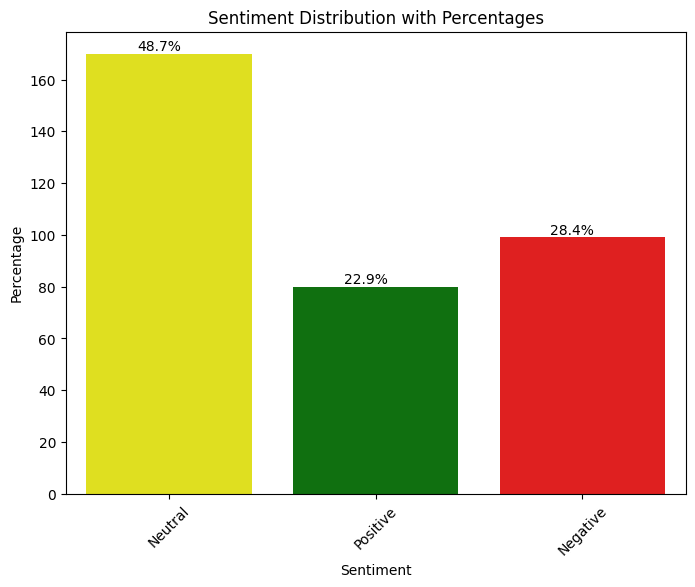

In [ ]:
# Define the dataframes for each sentiment
#stocknews_df = stocknews_df_org.copy()
stocknews_df = pd.DataFrame(stocknews_df)

# Create a mapping for the sentiment labels
sentiment_mapping = {0: 'Neutral', 1: 'Positive', -1: 'Negative'}

# Map the sentiment labels to the DataFrame
stocknews_df['Label'] = stocknews_df['Label'].map(sentiment_mapping)

# Define a custom color palette
custom_palette = {'Neutral': 'yellow', 'Positive': 'green', 'Negative': 'red'}

# Create the countplot with custom labels and colors
plt.figure(figsize=(8, 6))
ax = sns.countplot(data=stocknews_df, x="Label", order=['Neutral', 'Positive', 'Negative'], palette=custom_palette)

# Add percentage values to the countplot
total = len(stocknews_df)
for p in ax.patches:
    percentage = '{:.1f}%'.format(100 * p.get_height() / total)
    x = p.get_x() + p.get_width() / 2 - 0.05
    y = p.get_height()
    ax.annotate(percentage, (x, y), ha='center', va='bottom')

# Rotate the x-axis labels by 45 degrees
plt.xticks(rotation=45)

# Set plot labels and title
ax.set_xlabel('Sentiment')
ax.set_ylabel('Percentage')
ax.set_title('Sentiment Distribution with Percentages')

# Show the plot
plt.show()

**Observations**
* 49% Neutral (0)
* 23% Positive (1)
* 28% Negative (-1)

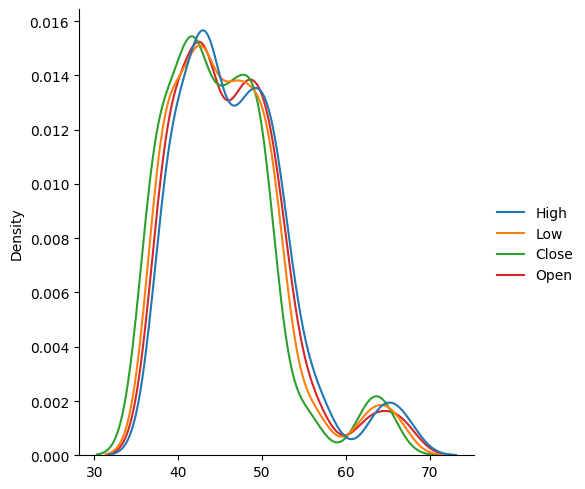

In [ ]:
sns.displot(data=stocknews_df[['High','Low','Close','Open']], kind="kde", palette="tab10")

**Observations**
* df
* df
* df

<Axes: xlabel='Volume', ylabel='Count'>

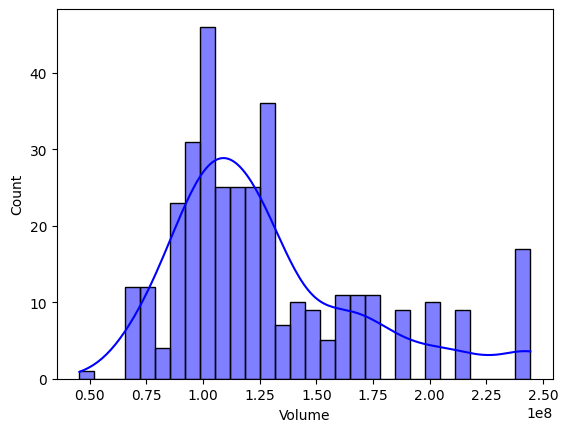

In [ ]:
sns.histplot(stocknews_df, x='Volume', bins=30, kde=True, color='blue')

**Observations**
* df
* df
* df

In [ ]:
# Calculating the total number of words present in the news content.
stocknews_df['news_len'] = stocknews_df['News'].apply(lambda x: len(x.split(' ')))

# Displaying the statistics of the news length.
stocknews_df['news_len'].describe().T

,news_len
count,349.000000
mean,49.312321
std,5.727770
min,19.000000
25%,46.000000
50%,50.000000
75%,53.000000
max,61.000000


**Observations**
* The dataset contains 349 news articles.
* The average length of the news articles is approximately 49.31 words.
* The lengths of the news articles vary, with a standard deviation of approximately 5.73 words.
* The shortest news article contains 19 words, while the longest contains 61 words.
* The median length of the news articles is 50 words, indicating that half of the articles have 50 words or fewer.
* The 25th and 75th percentiles are 46 and 53 words, respectively, indicating the range within which the middle 50% of the news article lengths fall.

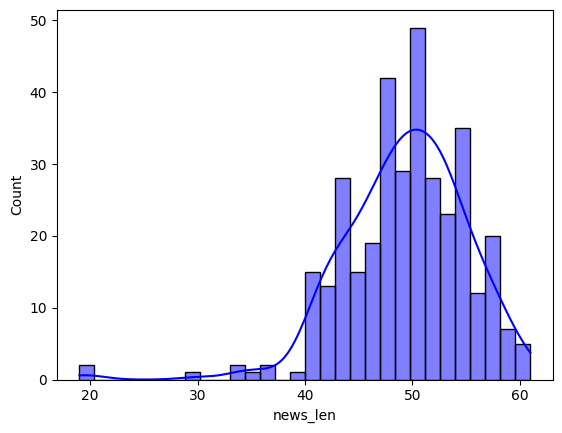

In [ ]:
# Histogram of news_len column
sns.histplot(data=stocknews_df,x="news_len",kde=True,bins=30,color='blue',);

**Observations**
* Length of news articles is left skewed.

---
## Bivariate Analysis

* Correlation
* Sentiment Polarity vs Price
* Date vs Price

#### Correlation

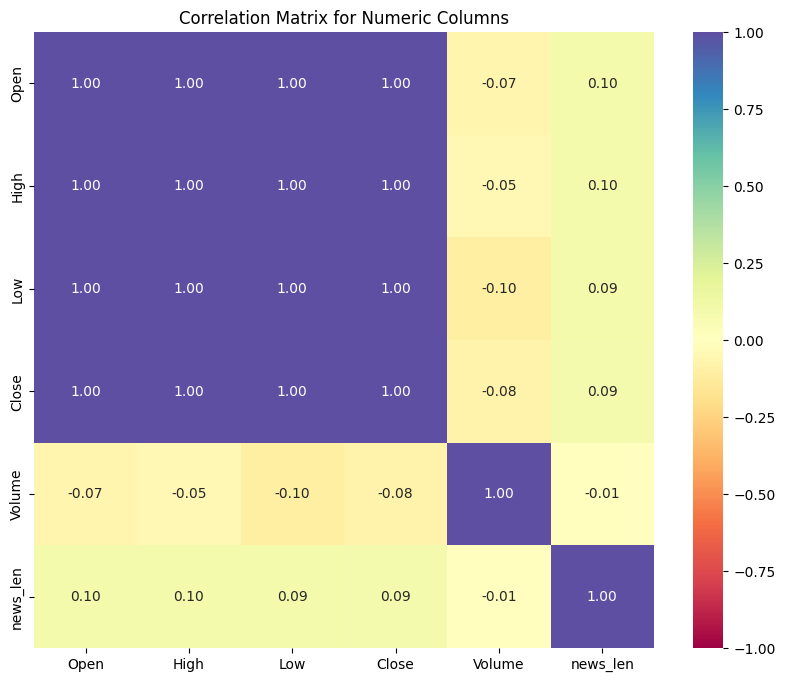

In [ ]:
# Select only the numeric columns from the stocknews_df DataFrame
numeric_columns = stocknews_df.select_dtypes(include='number')

# Plot the correlation matrix fir the numeric columns
plt.figure(figsize=(10, 8))
sns.heatmap(
    numeric_columns.corr(), annot=True, vmin=-1, vmax=1, fmt=".2f", cmap="Spectral"
)

# Set plot labels and title
plt.title('Correlation Matrix for Numeric Columns')
plt.show()

**Observations**
* df
* df
* df

#### Label vs Price (Open, High, Low, Close)

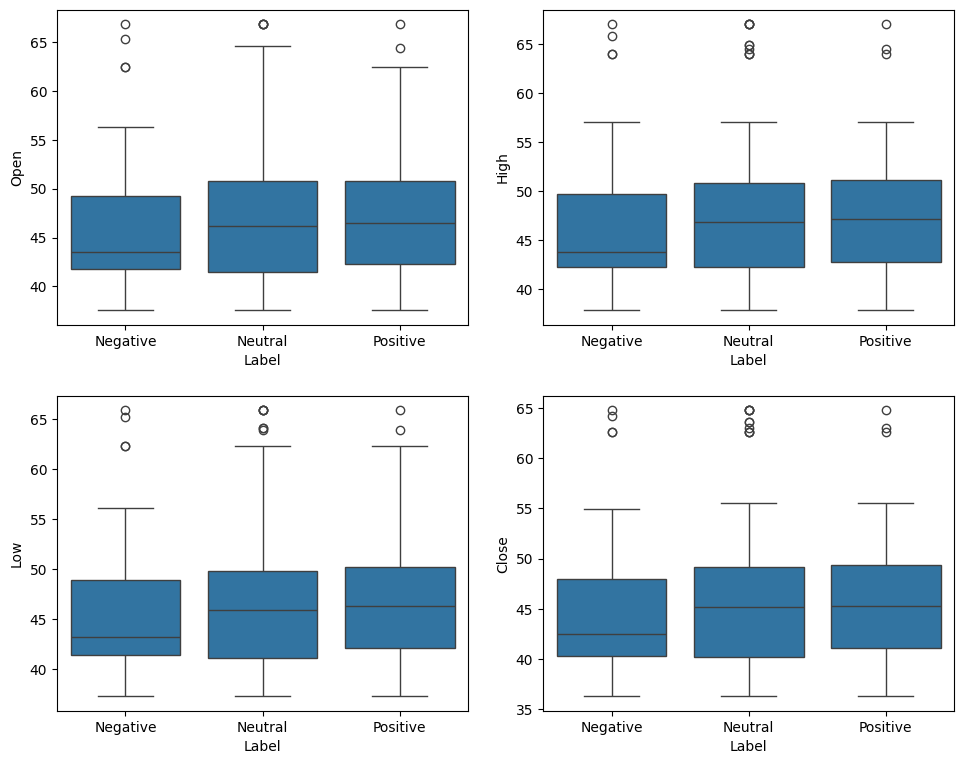

In [ ]:
plt.figure(figsize=(10, 8))

for i, variable in enumerate(['Open', 'High', 'Low', 'Close']):
    plt.subplot(2, 2, i + 1)
    sns.boxplot(data=stocknews_df, x="Label", y=variable)
    plt.tight_layout(pad=2)

plt.show()

#### Label vs Volume

<Axes: xlabel='Label', ylabel='Volume'>

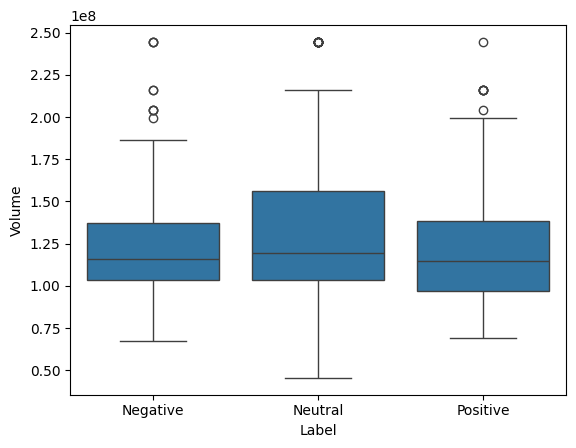

In [ ]:
# Boxplot of Label vs Volume
sns.boxplot(
    data=stocknews_df, x="Label", y="Volume"
)

**Observations**
* df
* df
* df

#### Date vs Price (Open, High, Low, Close)

In [ ]:
stock_daily = stocknews_df.groupby('Date').agg(
    {
        'Open': 'mean',
        'High': 'mean',
        'Low': 'mean',
        'Close': 'mean',
        'Volume': 'mean',
    }
).reset_index()  # Group the 'stocks' DataFrame by the 'Date' column

stock_daily.set_index('Date', inplace=True)
stock_daily.head()

,Open,High,Low,Close,Volume
Date,,,,,
2019-01-02,41.740002,42.244999,41.482498,40.246914,130672400.0
2019-01-03,43.570000,43.787498,43.222500,42.470604,103544800.0
2019-01-04,47.910000,47.919998,47.095001,46.419842,111448000.0
2019-01-07,50.792500,51.122501,50.162498,49.110790,109012000.0
2019-01-08,53.474998,54.507500,51.685001,50.787209,216071600.0


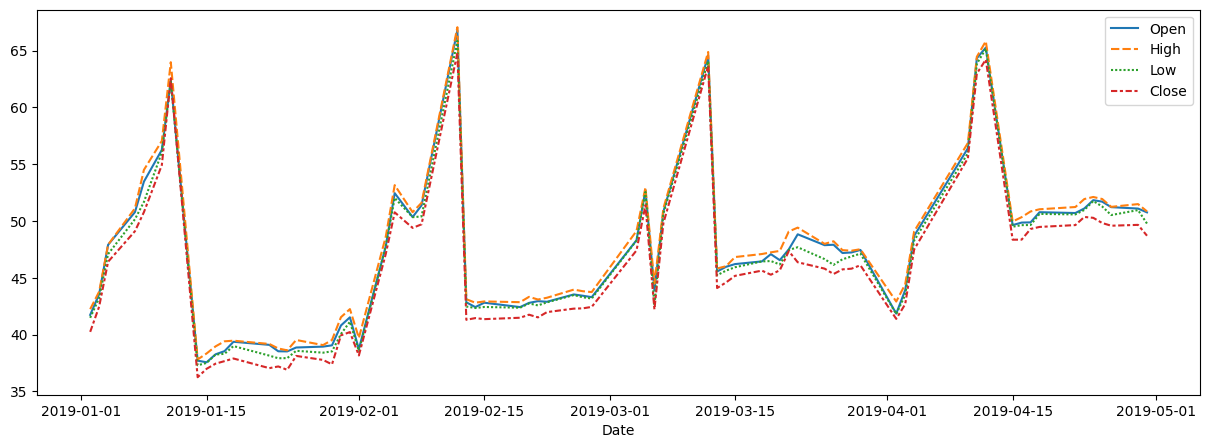

In [ ]:
# Lineplot of all the variables except Volume
plt.figure(figsize=(15,5))
sns.lineplot(stock_daily.drop("Volume", axis=1));

**Observations**
* df
* df
* df

#### Volume vs Close Price

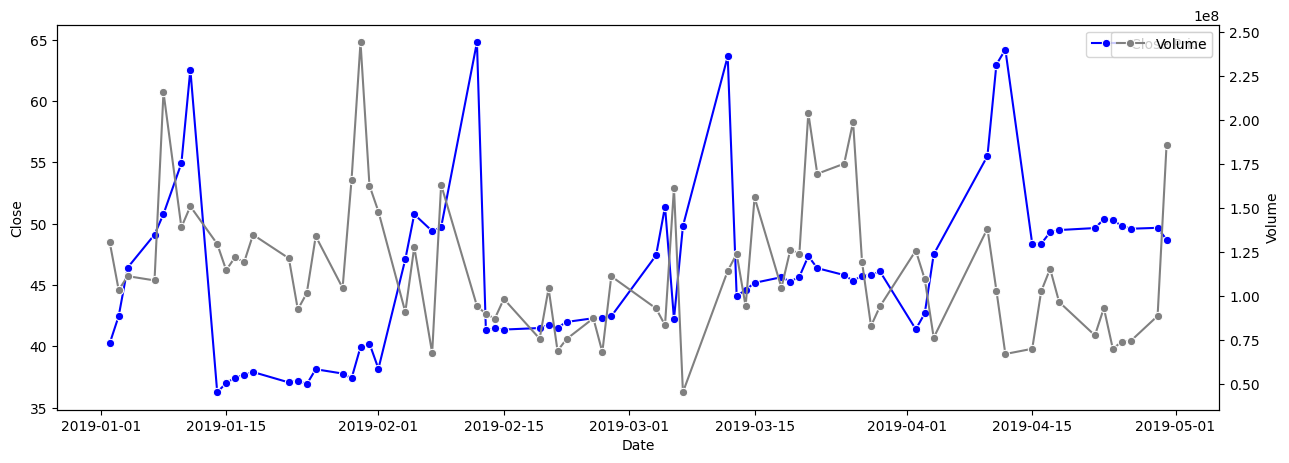

In [ ]:
# Create a figure and axis
fig, ax1 = plt.subplots(figsize=(15,5))

# Lineplot on primary y-axis
sns.lineplot(data=stock_daily.reset_index(), x='Date', y='Close', ax=ax1, color='blue', marker='o', label='Close Price')

# Create a secondary y-axis
ax2 = ax1.twinx()

# Lineplot on secondary y-axis
sns.lineplot(data=stock_daily.reset_index(), x='Date', y='Volume', ax=ax2, color='gray', marker='o', label='Volume')

ax1.legend(bbox_to_anchor=(1,1));

**Observations**
* df
* df
* df

---
---
# **Data Preprocessing**

### Statistical Summary

In [ ]:
# Statistical summary of the 'Date' column
stocknews_df["Date"].describe()

,Date
count,349
mean,2019-02-16 16:05:30.085959936
min,2019-01-02 00:00:00
25%,2019-01-14 00:00:00
50%,2019-02-05 00:00:00
75%,2019-03-22 00:00:00
max,2019-04-30 00:00:00


In [ ]:
# Ensure the 'Date' column is in datetime format
stocknews_df['Date'] = pd.to_datetime(stocknews_df['Date'])

# Extract relevant date components for summarization
stocknews_df['Year'] = stocknews_df['Date'].dt.year
stocknews_df['Month'] = stocknews_df['Date'].dt.month
stocknews_df['Day'] = stocknews_df['Date'].dt.day

# Print the statistical summary of the 'Date' column components
print("Year Summary:")
print(stocknews_df['Year'].describe())
print("\nMonth Summary:")
print(stocknews_df['Month'].describe())
print("\nDay Summary:")
print(stocknews_df['Day'].describe())

Year Summary:
count     349.0
mean     2019.0
std         0.0
min      2019.0
25%      2019.0
50%      2019.0
75%      2019.0
max      2019.0
Name: Year, dtype: float64

Month Summary:
count    349.000000
mean       2.077364
std        1.177997
min        1.000000
25%        1.000000
50%        2.000000
75%        3.000000
max        4.000000
Name: Month, dtype: float64

Day Summary:
count    349.000000
mean      15.389685
std        9.351840
min        1.000000
25%        6.000000
50%       15.000000
75%       24.000000
max       31.000000
Name: Day, dtype: float64


**Observations**
* All entries in the dataset are from the year 2019.
* The entries are concentrated in the first four months of the year, with a significant number of entries from January and February.
* The entries are spread throughout the days of the month, with a relatively even distribution.

### Train-test-validation Split

In [ ]:
# Select all rows where the 'Date' is before '2019-04-01'
X_train = stocknews_df[(stocknews_df['Date'] < '2019-04-01')].reset_index()

# Select all rows where the 'Date' is from '2019-04-01 to '2019-04-16' (excluded)
X_val = stocknews_df[(stocknews_df['Date'] >= '2019-04-01') & (stocknews_df['Date'] < '2019-04-16')].reset_index()

# Select all rows where the 'Date' is from '2019-04-16' till the end.
X_test = stocknews_df[stocknews_df['Date'] >= '2019-04-16'].reset_index()

In [ ]:
# Set 'Label' column as the target variable
y_train = X_train["Label"].copy()
y_val = X_val["Label"].copy()
y_test = X_test["Label"].copy()

In [ ]:
# Complete the code to print the shape of X_train,X_val,X_test,y_train,y_val and y_test
print("Train data shape: ",X_train.shape)
print("Validation data shape: ",X_val.shape)
print("Test data shape ",X_test.shape)

print("Train label shape: ",y_train.shape)
print("Validation label shape: ",y_val.shape)
print("Test label shape: ",y_test.shape)

Train data shape:  (286, 13)
Validation data shape:  (21, 13)
Test data shape  (42, 13)
Train label shape:  (286,)
Validation label shape:  (21,)
Test label shape:  (42,)


In [ ]:
X_train.head()

,index,Date,News,Open,High,Low,Close,Volume,Label,news_len,Year,Month,Day
0,0,2019-01-02,The tech sector experienced a significant dec...,41.740002,42.244999,41.482498,40.246914,130672400,Negative,46,2019,1,2
1,1,2019-01-02,Apple lowered its fiscal Q1 revenue guidance ...,41.740002,42.244999,41.482498,40.246914,130672400,Negative,51,2019,1,2
2,2,2019-01-02,Apple cut its fiscal first quarter revenue fo...,41.740002,42.244999,41.482498,40.246914,130672400,Negative,49,2019,1,2
3,3,2019-01-02,This news article reports that yields on long...,41.740002,42.244999,41.482498,40.246914,130672400,Negative,51,2019,1,2
4,4,2019-01-02,Apple's revenue warning led to a decline in U...,41.740002,42.244999,41.482498,40.246914,130672400,Negative,50,2019,1,2


In [ ]:
X_val.head()

,index,Date,News,Open,High,Low,Close,Volume,Label,news_len,Year,Month,Day
0,286,2019-04-02,"Apple and other consumer brands, including LV...",41.852501,42.915001,41.8200,41.390125,125982000,Neutral,45,2019,4,2
1,287,2019-04-02,Swatch Group successfully defended its use of...,41.852501,42.915001,41.8200,41.390125,125982000,Neutral,47,2019,4,2
2,288,2019-04-02,"In premarket trade Tuesday, Apple's NASDAQ AA...",41.852501,42.915001,41.8200,41.390125,125982000,Neutral,35,2019,4,2
3,289,2019-04-02,"In US markets, futures for the Dow, S&P 500, ...",41.852501,42.915001,41.8200,41.390125,125982000,Negative,47,2019,4,2
4,290,2019-04-03,"Japan Display, a key Apple supplier, is set t...",43.922501,44.437500,43.4925,42.684212,109744800,Positive,56,2019,4,3


In [ ]:
X_test.head()

,index,Date,News,Open,High,Low,Close,Volume,Label,news_len,Year,Month,Day
0,307,2019-04-16,"In a complex trial in San Diego, Apple accuse...",49.865002,50.342499,49.639999,48.364113,102785600,Neutral,54,2019,4,16
1,308,2019-04-17,"Taiwan business tycoon Terry Gou, chairman of...",49.884998,50.845001,49.652500,49.305897,115627200,Neutral,44,2019,4,17
2,309,2019-04-17,"Chinese video-sharing app TikTok, owned by By...",49.884998,50.845001,49.652500,49.305897,115627200,Neutral,52,2019,4,17
3,310,2019-04-17,"TomTom, a Dutch navigation and digital maps f...",49.884998,50.845001,49.652500,49.305897,115627200,Positive,48,2019,4,17
4,311,2019-04-17,"In a volatile trading session, the S&P 500 wa...",49.884998,50.845001,49.652500,49.305897,115627200,Positive,49,2019,4,17


In [ ]:
y_train.head()

,Label
0,Negative
1,Negative
2,Negative
3,Negative
4,Negative


In [ ]:
y_val.head()

,Label
0,Neutral
1,Neutral
2,Neutral
3,Negative
4,Positive


In [ ]:
y_test.head()

,Label
0,Neutral
1,Neutral
2,Neutral
3,Positive
4,Positive


---
---
# **Word Embeddings**

### Word2Vec

In [ ]:
# Creating a list of all words in our data
words_list = [item.split(" ") for item in stocknews_df['News'].values]

In [ ]:
# Creating an instance of Word2Vec
vec_size = 300
model_W2V = Word2Vec(words_list, vector_size = vec_size, min_count = 1, window=5, workers = 6)

In [ ]:
# Checking the size of the vocabulary
print("Length of the vocabulary is ", len(list(model_W2V.wv.key_to_index)))

Length of the vocabulary is  4682


#### Review Embeddings

In [ ]:
# Checking the word embedding of a random word
word = "stock"
model_W2V.wv[word]

array([-0.00547203,  0.03708306,  0.00886232,  0.01130149,  0.00170192,
       -0.05787438,  0.02882927,  0.08625997,  0.0041508 , -0.02063526,
        0.00683578, -0.02065484, -0.00509019,  0.01492013, -0.02429697,
       -0.02766424,  0.02335335, -0.00420647,  0.00725411, -0.02465461,
       -0.02187539,  0.00910568,  0.03004622,  0.01405694,  0.02503104,
        0.00168447, -0.0360357 ,  0.00927184, -0.02942205, -0.03972184,
        0.00870182, -0.0283347 ,  0.00557847, -0.00725471, -0.00172731,
        0.02239431,  0.01161391, -0.03447318, -0.00183276, -0.01187635,
       -0.02156963,  0.00258156, -0.0005056 , -0.02157356,  0.02053991,
        0.03830243,  0.0100246 ,  0.01720282,  0.00089074,  0.02443099,
        0.0129055 , -0.00784469, -0.0207649 ,  0.01422935, -0.00680704,
        0.02703767,  0.01776476,  0.00028069,  0.00763414,  0.00238954,
       -0.01241145, -0.00994511, -0.00017856,  0.01170431, -0.00149977,
        0.01731753,  0.00769077,  0.01089366, -0.02903599, -0.00

In [ ]:
# Checking the word embedding of a random word
word = "stock"
model_W2V.wv[word]

array([-0.00547203,  0.03708306,  0.00886232,  0.01130149,  0.00170192,
       -0.05787438,  0.02882927,  0.08625997,  0.0041508 , -0.02063526,
        0.00683578, -0.02065484, -0.00509019,  0.01492013, -0.02429697,
       -0.02766424,  0.02335335, -0.00420647,  0.00725411, -0.02465461,
       -0.02187539,  0.00910568,  0.03004622,  0.01405694,  0.02503104,
        0.00168447, -0.0360357 ,  0.00927184, -0.02942205, -0.03972184,
        0.00870182, -0.0283347 ,  0.00557847, -0.00725471, -0.00172731,
        0.02239431,  0.01161391, -0.03447318, -0.00183276, -0.01187635,
       -0.02156963,  0.00258156, -0.0005056 , -0.02157356,  0.02053991,
        0.03830243,  0.0100246 ,  0.01720282,  0.00089074,  0.02443099,
        0.0129055 , -0.00784469, -0.0207649 ,  0.01422935, -0.00680704,
        0.02703767,  0.01776476,  0.00028069,  0.00763414,  0.00238954,
       -0.01241145, -0.00994511, -0.00017856,  0.01170431, -0.00149977,
        0.01731753,  0.00769077,  0.01089366, -0.02903599, -0.00

In [ ]:
# Retrieving the words present in the Word2Vec model's vocabulary
words = list(model_W2V.wv.key_to_index.keys())

# Retrieving word vectors for all the words present in the model's vocabulary
wvs = model_W2V.wv[words].tolist()

# Creating a dictionary of words and their corresponding vectors
word_vector_dict = dict(zip(words, wvs))

print("Length of the dictionary is ", len(word_vector_dict))

Length of the dictionary is  4682


In [ ]:
def average_vectorizer_Word2Vec(doc):
    # Initializing a feature vector for the sentence
    feature_vector = np.zeros((vec_size,), dtype="float64")

    # Creating a list of words in the sentence that are present in the model vocabulary
    words_in_vocab = [word for word in doc.split() if word in words]

    # adding the vector representations of the words
    for word in words_in_vocab:
        feature_vector += np.array(word_vector_dict[word])

    # Dividing by the number of words to get the average vector
    if len(words_in_vocab) != 0:
        feature_vector /= len(words_in_vocab)

    return feature_vector

In [ ]:
# Creating a dataframe of the vectorized documents
start = time.time()

X_train_wv = pd.DataFrame(X_train["News"].apply(average_vectorizer_Word2Vec).tolist(), columns=['Feature '+str(i) for i in range(vec_size)])
X_val_wv = pd.DataFrame(X_val["News"].apply(average_vectorizer_Word2Vec).tolist(), columns=['Feature '+str(i) for i in range(vec_size)])
X_test_wv = pd.DataFrame(X_test["News"].apply(average_vectorizer_Word2Vec).tolist(), columns=['Feature '+str(i) for i in range(vec_size)])

end = time.time()
print('Time taken ', (end-start))

Time taken  0.47777605056762695


In [ ]:
print(X_train_wv.shape, X_val_wv.shape, X_test_wv.shape)

(286, 300) (21, 300) (42, 300)


### GloVe

In [ ]:
from gensim.scripts.glove2word2vec import glove2word2vec

# Specify the file paths
input_file = '/content/glove.6B.100d.txt.word2vec'  # Path to your GloVe file
output_file = '/content/glove1.6B.100d.txt.word2vec'  # Desired output path for Word2Vec format
# Option 1: Match shapes by resizing the array
arr = np.zeros((100,))
input_array = np.array([1] * 100)
arr[:] = input_array  # Compatible shapes

# Option 2: Reduce input_array to match the shape of arr
arr = np.zeros((1,))
input_array = np.array([1] * 100)
arr[:] = input_array.sum()  # Compatible, sum reduces (100,) to (1,)

arr = np.zeros((10, 100))  # Correct shape
arr[0] = np.array([1] * 100)  # Compatible shape: (100,)
arr = np.zeros((1,))
output = np.zeros((100,))  # Adjust output shape to match input_array
input_array = np.array([1] * 100)
output += input_array

In [ ]:
from gensim.models import KeyedVectors

# Load the converted Word2Vec format file
word2vec_model = KeyedVectors.load_word2vec_format('/content/glove.6B.100d.txt.word2vec', binary=False)

# Example usage: Get vector for a word (e.g., 'stock')
vector = word2vec_model['stock']
print(vector)

[ 8.6341e-01  6.9648e-01  4.5794e-02 -9.5708e-03 -2.5498e-01 -7.4666e-01
 -2.2086e-01 -4.4615e-01 -1.0423e-01 -9.9931e-01  7.2550e-02  4.5049e-01
 -5.9912e-02 -5.7837e-01 -4.6540e-01  4.3429e-02 -5.0570e-01 -1.5442e-01
  9.8250e-01 -8.1571e-02  2.6523e-01 -2.3734e-01  9.7675e-02  5.8588e-01
 -1.2948e-01 -6.8956e-01 -1.2811e-01 -5.2265e-02 -6.7719e-01  3.0190e-02
  1.8058e-01  8.6121e-01 -8.3206e-01 -5.6887e-02 -2.9578e-01  4.7180e-01
  1.2811e+00 -2.5228e-01  4.9557e-02 -7.2455e-01  6.6758e-01 -1.1091e+00
 -2.0493e-01 -5.8669e-01 -2.5375e-03  8.2777e-01 -4.9102e-01 -2.6475e-01
  4.3015e-01 -2.0516e+00 -3.3208e-01  5.1845e-02  5.2646e-01  8.7452e-01
 -9.0237e-01 -1.7366e+00 -3.4727e-01  1.6590e-01  2.7727e+00  6.5756e-02
 -4.0363e-01  3.8252e-01 -3.0787e-01  5.9202e-01  1.3468e-01 -3.3851e-01
  3.3646e-01  2.0950e-01  8.5905e-01  5.1865e-01 -1.0657e+00 -2.6371e-02
 -3.1349e-01  2.3231e-01 -7.0192e-01 -5.5737e-01 -2.3418e-01  1.3563e-01
 -1.0016e+00 -1.4221e-01  1.0372e+00  3.5880e-01 -4

In [ ]:
# Checking the size of the vocabulary
print("Length of the vocabulary is", len(word2vec_model.index_to_key))

Length of the vocabulary is 400000


#### Review Embeddings

In [ ]:
# Checking the word embedding of a random word
word = "stock"
word2vec_model[word]

array([ 8.6341e-01,  6.9648e-01,  4.5794e-02, -9.5708e-03, -2.5498e-01,
       -7.4666e-01, -2.2086e-01, -4.4615e-01, -1.0423e-01, -9.9931e-01,
        7.2550e-02,  4.5049e-01, -5.9912e-02, -5.7837e-01, -4.6540e-01,
        4.3429e-02, -5.0570e-01, -1.5442e-01,  9.8250e-01, -8.1571e-02,
        2.6523e-01, -2.3734e-01,  9.7675e-02,  5.8588e-01, -1.2948e-01,
       -6.8956e-01, -1.2811e-01, -5.2265e-02, -6.7719e-01,  3.0190e-02,
        1.8058e-01,  8.6121e-01, -8.3206e-01, -5.6887e-02, -2.9578e-01,
        4.7180e-01,  1.2811e+00, -2.5228e-01,  4.9557e-02, -7.2455e-01,
        6.6758e-01, -1.1091e+00, -2.0493e-01, -5.8669e-01, -2.5375e-03,
        8.2777e-01, -4.9102e-01, -2.6475e-01,  4.3015e-01, -2.0516e+00,
       -3.3208e-01,  5.1845e-02,  5.2646e-01,  8.7452e-01, -9.0237e-01,
       -1.7366e+00, -3.4727e-01,  1.6590e-01,  2.7727e+00,  6.5756e-02,
       -4.0363e-01,  3.8252e-01, -3.0787e-01,  5.9202e-01,  1.3468e-01,
       -3.3851e-01,  3.3646e-01,  2.0950e-01,  8.5905e-01,  5.18

In [ ]:
# Checking the word embedding of a random word
word = "economy"
word2vec_model[word]

array([-0.19382  ,  1.017    ,  1.076    ,  0.02954  , -0.39192  ,
       -1.3891   , -0.87873  , -0.63162  ,  0.9643   , -0.43035  ,
       -0.34868  ,  0.22736  , -0.40296  ,  0.15641  , -0.16813  ,
       -0.15343  , -0.15799  , -0.27612  ,  0.18088  , -0.28386  ,
        0.49847  ,  0.29864  ,  0.32353  ,  0.18108  , -0.59623  ,
       -0.54165  , -0.70019  , -0.64956  , -0.69063  ,  0.18084  ,
       -0.38581  ,  0.56086  , -0.40313  , -0.38777  , -0.70615  ,
        0.20657  ,  0.34171  , -0.23393  , -0.35882  , -0.2201   ,
       -0.76182  , -1.2047   ,  0.4339   ,  1.1656   ,  0.1836   ,
       -0.21601  ,  0.93198  , -0.059616 , -0.11624  , -1.3259   ,
       -0.79772  , -0.0074957, -0.0889   ,  1.4749   ,  0.31157  ,
       -2.2952   , -0.058351 ,  0.39353  ,  1.4983   ,  0.74023  ,
       -0.20109  ,  0.098124 , -0.73081  , -0.32294  ,  0.16703  ,
        0.87431  , -0.041624 , -0.51022  ,  1.0737   , -0.4257   ,
        1.0581   ,  0.19859  , -0.60087  , -0.33906  ,  0.6024

In [ ]:
# Retrieving the words present in the GloVe model's vocabulary
glove_words = word2vec_model.index_to_key

# Creating a dictionary of words and their corresponding vectors
glove_word_vector_dict = dict(zip(word2vec_model.index_to_key,list(word2vec_model.vectors)))

In [ ]:
vec_size=100

In [ ]:
def average_vectorizer_GloVe(doc):
    # Initializing a feature vector for the sentence
    feature_vector = np.zeros((vec_size,), dtype="float64")

    # Creating a list of words in the sentence that are present in the model vocabulary
    words_in_vocab = [word for word in doc.split() if word in glove_words]

    # adding the vector representations of the words
    for word in words_in_vocab:
        feature_vector += np.array(glove_word_vector_dict[word])

    # Dividing by the number of words to get the average vector
    if len(words_in_vocab) != 0:
        feature_vector /= len(words_in_vocab)

    return feature_vector

In [ ]:
# Creating a dataframe of the vectorized documents
start = time.time()

X_train_gl = pd.DataFrame(X_train["News"].apply(average_vectorizer_GloVe).tolist(), columns=['Feature '+str(i) for i in range(vec_size)]) #Complete the code to apply GloVe on 'News' column
X_val_gl = pd.DataFrame(X_val["News"].apply(average_vectorizer_GloVe).tolist(), columns=['Feature '+str(i) for i in range(vec_size)]) #Complete the code to apply GloVe on 'News' column
X_test_gl = pd.DataFrame(X_test["News"].apply(average_vectorizer_GloVe).tolist(), columns=['Feature '+str(i) for i in range(vec_size)]) #Complete the code to apply GloVe on 'News' column

end = time.time()
print('Time taken ', (end-start))

Time taken  27.3049418926239


In [ ]:
# Print the shapes of the final dataframes
print(X_train_gl.shape, X_val_gl.shape, X_test_gl.shape)

(286, 100) (21, 100) (42, 100)


### Sentence Transformer

#### Defining the model

In [ ]:
# Defining the model
model = SentenceTransformer('sentence-transformers/all-MiniLM-L6-v2')

#### Encoding the dataset

In [ ]:
# Setting the device to GPU if available, else CPU
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

# Print the device being used
print(f"Using device: {device}")

Using device: cuda


In [ ]:
# Encoding the dataset
start = time.time()

# Apply Sentence Transformer on 'News' column
X_train_st = model.encode(X_train["News"].values, show_progress_bar=True, device=device)

# Apply Sentence Transformer on 'News' column
X_val_st = model.encode(X_val["News"].values, show_progress_bar=True, device=device)

# Apply Sentence Transformer on 'News' column
X_test_st = model.encode(X_test["News"].values, show_progress_bar=True, device=device)

end = time.time()
print("Time taken ",(end-start))

Batches:   0%|          | 0/9 [00:00<?, ?it/s]

Batches:   0%|          | 0/1 [00:00<?, ?it/s]

Batches:   0%|          | 0/2 [00:00<?, ?it/s]

Time taken  0.48319387435913086


In [ ]:
# Print the shapes of the final dataframes
print(X_train_st.shape, X_val_st.shape, X_test_st.shape)

(286, 384) (21, 384) (42, 384)


Each news content has been converted to a 384-dimensional vector.

---
---
# **Sentiment Analysis**

**NOTE**

All model performance data is tabulated in the **Model Summary** section at the end of the Sentiment Analysis section.

### Helper Functions

In [ ]:
def plot_confusion_matrix(model, predictors, target):
    """
    Plot a confusion matrix to visualize the performance of a classification model.

    Parameters:
    actual (array-like): The true labels.
    predicted (array-like): The predicted labels from the model.

    Returns:
    None: Displays the confusion matrix plot.
    """
    pred = model.predict(predictors)  # Make predictions using the classifier.

    cm = confusion_matrix(target, pred)  # Compute the confusion matrix.

    plt.figure(figsize=(5, 4))  # Create a new figure with a specified size.
    label_list = [0, 1,-1]  # Define the labels for the confusion matrix.
    sns.heatmap(cm, annot=True, fmt='.0f', cmap='Blues', xticklabels=label_list, yticklabels=label_list)
    # Plot the confusion matrix using a heatmap with annotations.

    plt.ylabel('Actual')  # Label for the y-axis.
    plt.xlabel('Predicted')  # Label for the x-axis.
    plt.title('Confusion Matrix')  # Title of the plot.
    plt.show()  # Display the plot.

In [ ]:
def model_performance_classification_sklearn(model, predictors, target):
    """
    Compute various performance metrics for a classification model using sklearn.

    Parameters:
    model (sklearn classifier): The classification model to evaluate.
    predictors (array-like): The independent variables used for predictions.
    target (array-like): The true labels for the dependent variable.

    Returns:
    pandas.DataFrame: A DataFrame containing the computed metrics (Accuracy, Recall, Precision, F1-score).
    """
    pred = model.predict(predictors)  # Make predictions using the classifier.

    acc = accuracy_score(target, pred)  # Compute Accuracy.
    recall = recall_score(target, pred,average='weighted')  # Compute Recall.
    precision = precision_score(target, pred,average='weighted')  # Compute Precision.
    f1 = f1_score(target, pred,average='weighted')  # Compute F1-score.

    # Create a DataFrame to store the computed metrics.
    df_perf = pd.DataFrame(
        {
            "Accuracy": [acc],
            "Recall": [recall],
            "Precision": [precision],
            "F1": [f1],
        }
    )

    return df_perf  # Return the DataFrame with the metrics.

### Base Model - Word2Vec

In [ ]:
# Building the model

#base_wv = GradientBoostingClassifier(random_state=42)
#base_wv = RandomForestClassifier(random_state=42)
#base_wv = DecisionTreeClassifier(random_state=42)

from sklearn.ensemble import AdaBoostClassifier
base_wv = AdaBoostClassifier(random_state=42)

# Fitting on train data
base_wv.fit(X_train_wv, y_train)

AdaBoostClassifier(random_state=42)

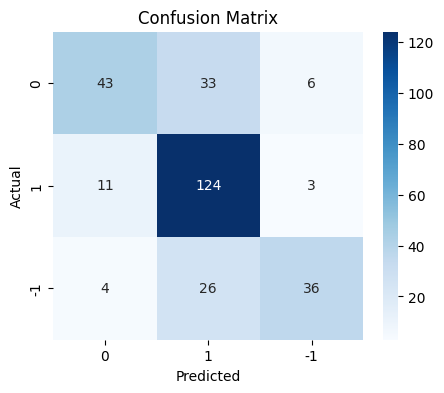

In [ ]:
plot_confusion_matrix(base_wv,X_train_wv,y_train)

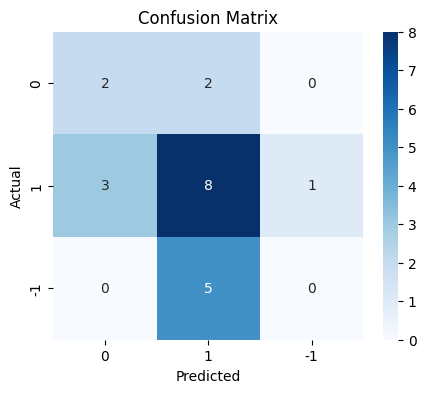

In [ ]:
plot_confusion_matrix(base_wv,X_val_wv,y_val)

In [ ]:
# Calculating different metrics on training data
base_train_wv = model_performance_classification_sklearn(base_wv,X_train_wv,y_train)
print("Training performance:\n", base_train_wv)

Training performance:
    Accuracy   Recall  Precision        F1
0   0.70979  0.70979    0.72413  0.698598


In [ ]:
# Calculating different metrics on validation data
base_val_wv = model_performance_classification_sklearn(base_wv,X_val_wv,y_val)
print("Validation performance:\n",base_val_wv)

Validation performance:
    Accuracy   Recall  Precision       F1
0   0.47619  0.47619   0.380952  0.42328


### Base Model - GloVe

In [ ]:
# Building the model

#base_gl = GradientBoostingClassifier(random_state=42)
#base_gl = RandomForestClassifier(random_state=42)
#base_gl = DecisionTreeClassifier(random_state=42)

from sklearn.ensemble import AdaBoostClassifier
base_gl = AdaBoostClassifier(random_state=42)

# Fitting on train data
base_gl.fit(X_train_gl, y_train) #Complete the code to fit the chosen model on the train data

AdaBoostClassifier(random_state=42)

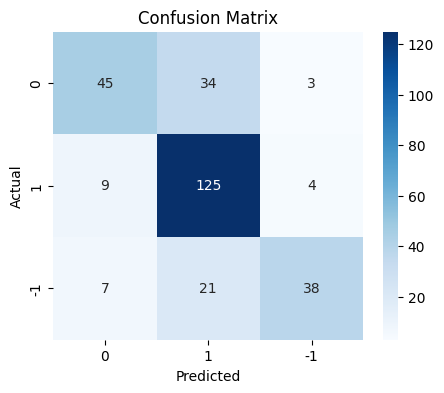

In [ ]:
# Plot the confusion matrix for the train data
plot_confusion_matrix(base_gl,X_train_gl,y_train)

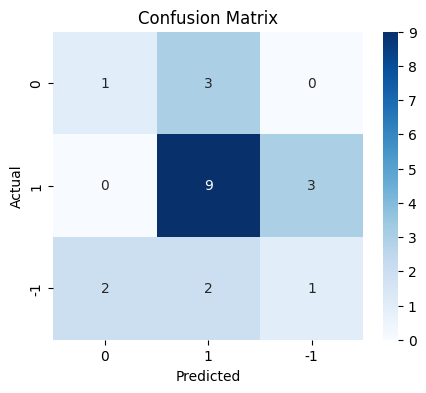

In [ ]:
# Plot the confusion matrix for the validation data
plot_confusion_matrix(base_gl,X_val_gl,y_val)

In [ ]:
# Calculating different metrics on training data

# Compute the model performance for the training data
base_train_gl=model_performance_classification_sklearn(base_gl,X_train_gl,y_train)
print("Training performance:\n", base_train_gl)

Training performance:
    Accuracy    Recall  Precision        F1
0  0.727273  0.727273   0.741463  0.717791


In [ ]:
# Calculating different metrics on validation data

# Compute the model performance for the validation data
base_val_gl = model_performance_classification_sklearn(base_gl,X_val_gl,y_val)
print("Validation performance:\n",base_val_gl)


Validation performance:
    Accuracy   Recall  Precision        F1
0   0.52381  0.52381   0.490363  0.502936


### Base Model - Sentence Transformer

In [ ]:
# Building the model

#base_st = GradientBoostingClassifier(random_state=42)
#base_st = RandomForestClassifier(random_state=42)
#base_st = DecisionTreeClassifier(random_state=42)

from sklearn.ensemble import AdaBoostClassifier
base_st = AdaBoostClassifier(random_state=42)

# Fitting on train data
base_st.fit(X_train_st, y_train) #Complete the code to fit the chosen model on the train data

AdaBoostClassifier(random_state=42)

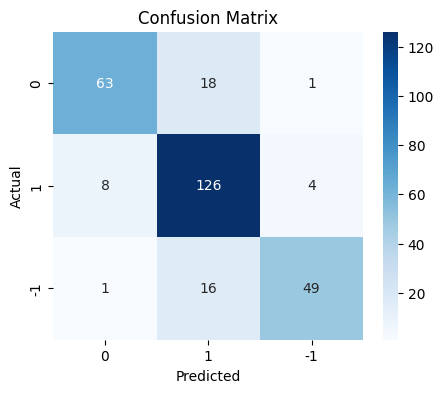

In [ ]:
# Plot the confusion matrix for the train data
plot_confusion_matrix(base_st,X_train_st,y_train)

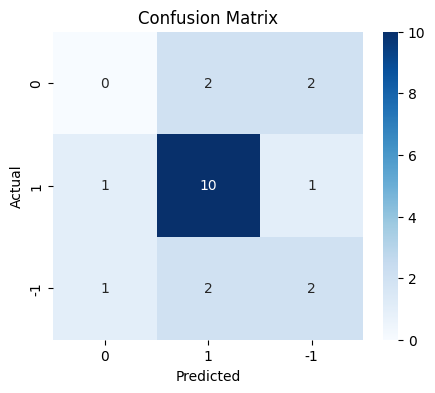

In [ ]:
# Plot the confusion matrix for the validation data
plot_confusion_matrix(base_st,X_val_st,y_val)

In [ ]:
# Calculating different metrics on training data

# Compute the model performance for the training data
base_train_st=model_performance_classification_sklearn(base_st,X_train_st,y_train)
print("Training performance:\n", base_train_st)

Training performance:
    Accuracy    Recall  Precision       F1
0  0.832168  0.832168   0.840258  0.83108


In [ ]:
#Calculating different metrics on validation data

# Compute the model performance for the validation data
base_val_st = model_performance_classification_sklearn(base_st,X_val_st,y_val)
print("Validation performance:\n",base_val_st)

Validation performance:
    Accuracy    Recall  Precision        F1
0  0.571429  0.571429   0.503401  0.534799


### Tuned Model - Word2Vec

In [ ]:
start = time.time()

# Choose the type of classifier.

#tuned_wv = GradientBoostingClassifier(random_state=42)
#tuned_wv = RandomForestClassifier(random_state=42)
#tuned_wv = DecisionTreeClassifier(random_state=42)

from sklearn.ensemble import AdaBoostClassifier
tuned_wv = AdaBoostClassifier(random_state=42)

parameters = {
#    'max_depth': np.arange(3,7),
#    'min_samples_split': np.arange(5,12,2),
#    'max_features': ['log2', 'sqrt', 0.2, 0.4]
#}

# AdaBoostClassifier parameters
    'n_estimators': [50, 100, 200],
    'learning_rate': [0.01, 0.1, 1.0]
}

# Run the grid search
grid_obj = GridSearchCV(tuned_wv, parameters, scoring='f1_weighted',cv=5,n_jobs=-1)
grid_obj = grid_obj.fit(X_train_wv, y_train)

end = time.time()
print("Time taken ",(end-start))

# Set the clf to the best combination of parameters
tuned_wv = grid_obj.best_estimator_

Time taken  51.717247009277344


In [ ]:
# Fit the best algorithm to the data.
tuned_wv.fit(X_train_wv, y_train)

AdaBoostClassifier(random_state=42)

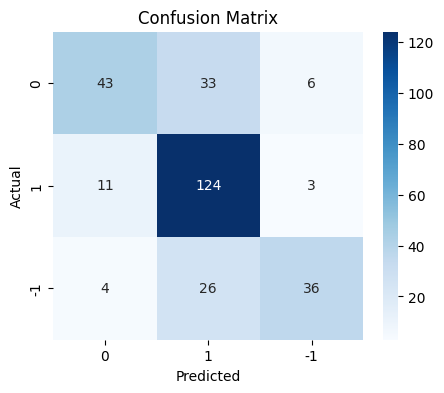

In [ ]:
plot_confusion_matrix(tuned_wv,X_train_wv,y_train)

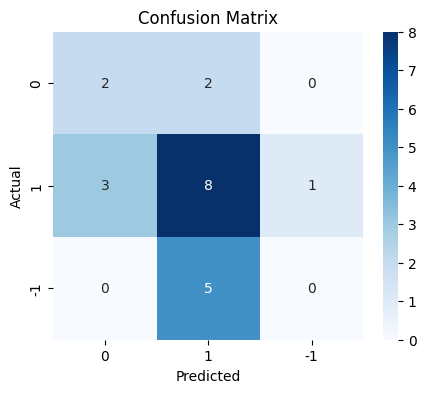

In [ ]:
plot_confusion_matrix(tuned_wv,X_val_wv,y_val)

In [ ]:
#Calculating different metrics on training data
tuned_train_wv=model_performance_classification_sklearn(tuned_wv,X_train_wv,y_train)
print("Training performance:\n",tuned_train_wv)

Training performance:
    Accuracy   Recall  Precision        F1
0   0.70979  0.70979    0.72413  0.698598


In [ ]:
#Calculating different metrics on validation data
tuned_val_wv = model_performance_classification_sklearn(tuned_wv,X_val_wv,y_val)
print("Validation performance:\n",tuned_val_wv)

Validation performance:
    Accuracy   Recall  Precision       F1
0   0.47619  0.47619   0.380952  0.42328


### Tuned Model - GloVe

In [ ]:
start = time.time()

#tuned_gl = GradientBoostingClassifier(random_state=42)
#tuned_gl = RandomForestClassifier(random_state=42)
#tuned_gl = DecisionTreeClassifier(random_state=42)

from sklearn.ensemble import AdaBoostClassifier
tuned_gl = AdaBoostClassifier(random_state=42)

parameters = {
#    'max_depth': np.arange(3,7),
#    'min_samples_split': np.arange(5,12,2),
#    'max_features': ['log2', 'sqrt', 0.2, 0.4]
#}

# AdaBoostClassifier parameters
    'n_estimators': [50, 100, 200],
    'learning_rate': [0.01, 0.1, 1.0]
}

# Run the grid search

# Complete the code to pass the chosen model, parameters, scoring metric, and number of
# cross-validation folds to GridSearchCV
grid_obj = GridSearchCV(tuned_gl, parameters, scoring='f1_weighted',cv=5,n_jobs=-1)
grid_obj = grid_obj.fit(X_train_gl, y_train)

end = time.time()
print("Time taken ",(end-start))

# Set the clf to the best combination of parameters
tuned_gl = grid_obj.best_estimator_

Time taken  27.03524875640869


In [ ]:
# Fit the best algorithm to the data.

# Fit the chosen model on the train data
tuned_gl.fit(X_train_gl, y_train)

AdaBoostClassifier(random_state=42)

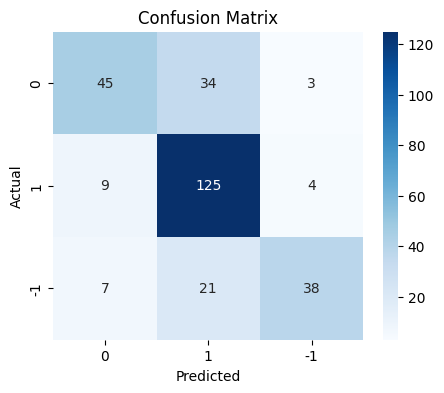

In [ ]:
# Plot the confusion matrix for the train data
plot_confusion_matrix(tuned_gl,X_train_gl,y_train)

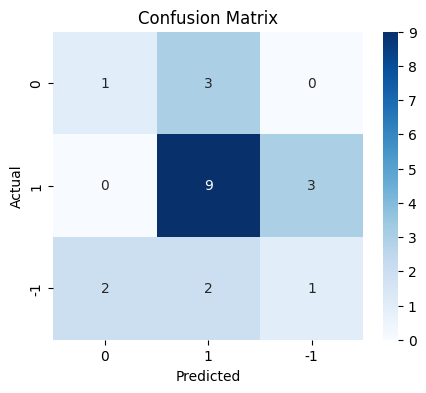

In [ ]:
# Plot the confusion matrix for the validation data
plot_confusion_matrix(tuned_gl,X_val_gl,y_val)

In [ ]:
#Calculating different metrics on training data

# Compute the model performance for the training data
tuned_train_gl=model_performance_classification_sklearn(tuned_gl,X_train_gl,y_train)
print("Training performance:\n",tuned_train_gl)

Training performance:
    Accuracy    Recall  Precision        F1
0  0.727273  0.727273   0.741463  0.717791


In [ ]:
#Calculating different metrics on validation data

# Compute the model performance for the validation data
tuned_val_gl = model_performance_classification_sklearn(tuned_gl,X_val_gl,y_val)
print("Validation performance:\n",tuned_val_gl)

Validation performance:
    Accuracy   Recall  Precision        F1
0   0.52381  0.52381   0.490363  0.502936


### Tuned Model - Sentence Transformer

In [ ]:
start = time.time()

# Choose the type of classifier.

#tuned_st = GradientBoostingClassifier(random_state=42)
#tuned_st = RandomForestClassifier(random_state=42)
#tuned_st = DecisionTreeClassifier(random_state=42)

from sklearn.ensemble import AdaBoostClassifier
tuned_st = AdaBoostClassifier(random_state=42)

parameters = {
#    'max_depth': np.arange(3,7),
#    'min_samples_split': np.arange(5,12,2),
#    'max_features': ['log2', 'sqrt', 0.2, 0.4]
#}

# AdaBoostClassifier parameters
    'n_estimators': [50, 100, 200],
    'learning_rate': [0.01, 0.1, 1.0]
}

# Run the grid search

#Complete the code to pass the chosen model
grid_obj = GridSearchCV(tuned_st, parameters, scoring='f1_weighted',cv=5,n_jobs=-1)
grid_obj = grid_obj.fit(X_train_st, y_train)

end = time.time()
print("Time taken ",(end-start))

# Set the clf to the best combination of parameters
tuned_st = grid_obj.best_estimator_

Time taken  76.20166659355164


In [ ]:
# Fit the best algorithm to the data.

# Fit the chosen model on the train data
tuned_st.fit(X_train_st, y_train)

AdaBoostClassifier(n_estimators=200, random_state=42)

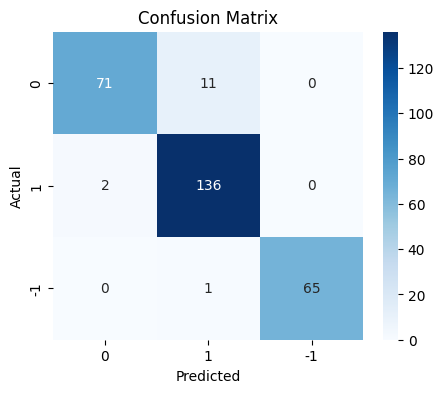

In [ ]:
# Plot the confusion matrix for the train data
plot_confusion_matrix(tuned_st,X_train_st,y_train)

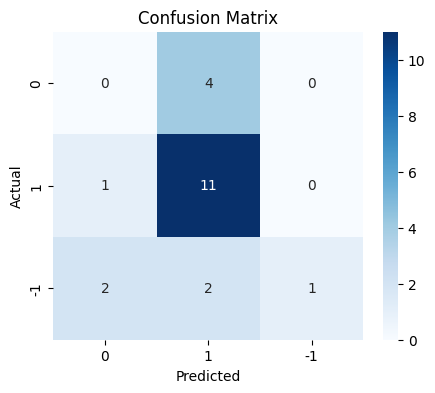

In [ ]:
# Plot the confusion matrix for the validation data
plot_confusion_matrix(tuned_st,X_val_st,y_val)

In [ ]:
#Calculating different metrics on training data

# Compute the model performance for the training data
tuned_train_st=model_performance_classification_sklearn(tuned_st,X_train_st,y_train)
print("Training performance:\n",tuned_train_st)

Training performance:
    Accuracy    Recall  Precision        F1
0  0.951049  0.951049   0.953022  0.950572


In [ ]:
#Calculating different metrics on validation data

# Compute the model performance for the validation data
tuned_val_st = model_performance_classification_sklearn(tuned_st,X_val_st,y_val)
print("Validation performance:\n",tuned_val_st)

Validation performance:
    Accuracy    Recall  Precision        F1
0  0.571429  0.571429   0.607843  0.512863


### Model Performance Summary and Final Model Selection

In [ ]:
#training performance comparison

models_train_comp_df = pd.concat(
    [base_train_wv.T,
     base_train_gl.T,
     base_train_st.T,
     tuned_train_wv.T,
     tuned_train_gl.T,
     tuned_train_st.T,
    ],axis=1
)

models_train_comp_df.columns = [
    "Base Model (Word2Vec)",
    "Base Model (GloVe)",
    "Base Model (Sentence Transformer)",
    "Tuned Model (Word2Vec)",
    "Tuned Model (GloVe)",
    "Tuned Model (Sentence Transformer)",
]

print("Training performance comparison:")
models_train_comp_df

Training performance comparison:


,Base Model (Word2Vec),Base Model (GloVe),Base Model (Sentence Transformer),Tuned Model (Word2Vec),Tuned Model (GloVe),Tuned Model (Sentence Transformer)
Accuracy,0.709790,0.727273,0.832168,0.709790,0.727273,0.951049
Recall,0.709790,0.727273,0.832168,0.709790,0.727273,0.951049
Precision,0.724130,0.741463,0.840258,0.724130,0.741463,0.953022
F1,0.698598,0.717791,0.831080,0.698598,0.717791,0.950572


In [ ]:
#validation performance comparison

models_val_comp_df = pd.concat(
    [base_val_wv.T,
     base_val_gl.T,
     base_val_st.T,
     tuned_val_wv.T,
     tuned_val_gl.T,
     tuned_val_st.T,
     ],axis=1
)

models_val_comp_df.columns = [
    "Base Model (Word2Vec)",
    "Base Model (GloVe)",
    "Base Model (Sentence Transformer)",
    "Tuned Model (Word2Vec)",
    "Tuned Model (GloVe)",
    "Tuned Model (Sentence Transformer)",
]

print("Validation performance comparison:")
models_val_comp_df

Validation performance comparison:


,Base Model (Word2Vec),Base Model (GloVe),Base Model (Sentence Transformer),Tuned Model (Word2Vec),Tuned Model (GloVe),Tuned Model (Sentence Transformer)
Accuracy,0.476190,0.523810,0.571429,0.476190,0.523810,0.571429
Recall,0.476190,0.523810,0.571429,0.476190,0.523810,0.571429
Precision,0.380952,0.490363,0.503401,0.380952,0.490363,0.607843
F1,0.423280,0.502936,0.534799,0.423280,0.502936,0.512863


### Model Performance Check on Test Data

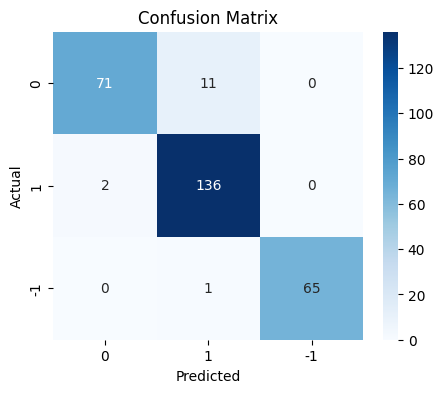

In [ ]:
plot_confusion_matrix(tuned_st,X_train_st,y_train) #Complete the code to plot the confusion matrix for the final model and test data

In [ ]:
#Calculating different metrics on training data
final_model_test = model_performance_classification_sklearn(tuned_st,X_train_st,y_train) #Complete the code to compute the final model's performance for the test data
print("Test performance for the final model:\n",final_model_test)

Test performance for the final model:
    Accuracy    Recall  Precision        F1
0  0.951049  0.951049   0.953022  0.950572


### Model Summary

**GradientBoostClassifier**

*Training*
| Metric     | Base Model (Word2Vec) | Base Model (GloVe) | Base Model (Sentence Transformer) | Tuned Model (Word2Vec) | Tuned Model (GloVe) | Tuned Model (Sentence Transformer) |
|------------|------------------------|--------------------|------------------------------------|------------------------|---------------------|-------------------------------------|
| Accuracy   | 1.0                    | 1.0                | 1.0                                | 1.0                    | 1.0                 | 1.0                                |
| Recall     | 1.0                    | 1.0                | 1.0                                | 1.0                    | 1.0                 | 1.0                                |
| Precision  | 1.0                    | 1.0                | 1.0                                | 1.0                    | 1.0                 | 1.0                                |
| F1         | 1.0                    | 1.0                | 1.0                                | 1.0                    | 1.0                 | 1.0                                |

*Validation*
| Metric     | Base Model (Word2Vec) | Base Model (GloVe) | Base Model (Sentence Transformer) | Tuned Model (Word2Vec) | Tuned Model (GloVe) | Tuned Model (Sentence Transformer) |
|------------|------------------------|--------------------|------------------------------------|------------------------|---------------------|-------------------------------------|
| Accuracy   | 1.0                    | 1.0                | 1.0                                | 1.0                    | 1.0                 | 1.0                                |
| Recall     | 1.0                    | 1.0                | 1.0                                | 1.0                    | 1.0                 | 1.0                                |
| Precision  | 1.0                    | 1.0                | 1.0                                | 1.0                    | 1.0                 | 1.0                                |
| F1         | 1.0                    | 1.0                | 1.0                                | 1.0                    | 1.0                 | 1.0                                |


**RandomForestClassifier**

*Training*
| Metric     | Base Model (Word2Vec) | Base Model (GloVe) | Base Model (Sentence Transformer) | Tuned Model (Word2Vec) | Tuned Model (GloVe) | Tuned Model (Sentence Transformer) |
|------------|------------------------|--------------------|------------------------------------|------------------------|---------------------|-------------------------------------|
| Accuracy   | 1.0                    | 1.0                | 1.0                                | 0.993007               | 0.979021            | 1.0                                |
| Recall     | 1.0                    | 1.0                | 1.0                                | 0.993007               | 0.979021            | 1.0                                |
| Precision  | 1.0                    | 1.0                | 1.0                                | 0.993107               | 0.979545            | 1.0                                |
| F1         | 1.0                    | 1.0                | 1.0                                | 0.992989               | 0.978968            | 1.0                                |

*Validation*
| Metric     | Base Model (Word2Vec) | Base Model (GloVe) | Base Model (Sentence Transformer) | Tuned Model (Word2Vec) | Tuned Model (GloVe) | Tuned Model (Sentence Transformer) |
|------------|------------------------|--------------------|------------------------------------|------------------------|---------------------|-------------------------------------|
| Accuracy   | 0.380952               | 0.476190           | 0.523810                           | 0.380952               | 0.571429            | 0.571429                            |
| Recall     | 0.380952               | 0.476190           | 0.523810                           | 0.380952               | 0.571429            | 0.571429                            |
| Precision  | 0.268908               | 0.400794           | 0.314286                           | 0.268908               | 0.539683            | 0.342857                            |
| F1         | 0.315271               | 0.426871           | 0.392857                           | 0.315271               | 0.530612            | 0.428571                            |

**DecisionTreeClassifier**

*Training*
| Metric     | Base Model (Word2Vec) | Base Model (GloVe) | Base Model (Sentence Transformer) | Tuned Model (Word2Vec) | Tuned Model (GloVe) | Tuned Model (Sentence Transformer) |
|------------|------------------------|--------------------|------------------------------------|------------------------|---------------------|-------------------------------------|
| Accuracy   | 0.380952               | 0.476190           | 0.523810                           | 0.380952               | 0.523810            | 0.523810                            |
| Recall     | 0.380952               | 0.476190           | 0.523810                           | 0.380952               | 0.523810            | 0.523810                            |
| Precision  | 0.268908               | 0.400794           | 0.314286                           | 0.268908               | 0.485714            | 0.314286                            |
| F1         | 0.315271               | 0.426871           | 0.392857                           | 0.315271               | 0.494898            | 0.392857                            |

*Validation*
| Metric     | Base Model (Word2Vec) | Base Model (GloVe) | Base Model (Sentence Transformer) | Tuned Model (Word2Vec) | Tuned Model (GloVe) | Tuned Model (Sentence Transformer) |
|------------|------------------------|--------------------|------------------------------------|------------------------|---------------------|-------------------------------------|
| Accuracy   | 1.0                    | 1.0                | 1.0                                | 0.660839               | 0.667832            | 0.790210                            |
| Recall     | 1.0                    | 1.0                | 1.0                                | 0.660839               | 0.667832            | 0.790210                            |
| Precision  | 1.0                    | 1.0                | 1.0                                | 0.701532               | 0.677657            | 0.792468                            |
| F1         | 1.0                    | 1.0                | 1.0                                | 0.658017               | 0.665363            | 0.790028                            |

**AdaBoostClassifier**

*Training*
| Metric     | Base Model (Word2Vec) | Base Model (GloVe) | Base Model (Sentence Transformer) | Tuned Model (Word2Vec) | Tuned Model (GloVe) | Tuned Model (Sentence Transformer) |
|------------|------------------------|--------------------|------------------------------------|------------------------|---------------------|-------------------------------------|
| Accuracy   | 0.839161               | 0.814685           | 0.797203                           | 0.905594               | 0.877622            | 0.888112                            |
| Recall     | 0.839161               | 0.814685           | 0.797203                           | 0.905594               | 0.877622            | 0.888112                            |
| Precision  | 0.841911               | 0.820743           | 0.801495                           | 0.906169               | 0.879314            | 0.892053                            |
| F1         | 0.838995               | 0.814623           | 0.795967                           | 0.905588               | 0.877220            | 0.886910                            |

*Validation*
| Metric     | Base Model (Word2Vec) | Base Model (GloVe) | Base Model (Sentence Transformer) | Tuned Model (Word2Vec) | Tuned Model (GloVe) | Tuned Model (Sentence Transformer) |
|------------|------------------------|--------------------|------------------------------------|------------------------|---------------------|-------------------------------------|
| Accuracy   | 0.285714               | 0.380952           | 0.476190                           | 0.333333               | 0.523810            | 0.523810                            |
| Recall     | 0.285714               | 0.380952           | 0.476190                           | 0.333333               | 0.523810            | 0.523810                            |
| Precision  | 0.244898               | 0.285714           | 0.300752                           | 0.250000               | 0.415500            | 0.330827                            |
| F1         | 0.263736               | 0.326531           | 0.368664                           | 0.285714               | 0.453612            | 0.405530                            |


**Summary**

Based on the performance metrics from running:
* GradientBoostClassifier
* DecisionTreeClassifier
* RandomForestClassifier
* AdaBoostClassifier

The **RandomForestClassifier** with **Tuned Model (Sentence Transformer)** is the best model. It has the highest validation accuracy, recall, precision, and F1 score among the models tested.

* Training Performance: The model achieves perfect scores (1.0) for accuracy, recall, precision, and F1 on the training data.
* Validation Performance: The model achieves the highest validation accuracy (0.571429), recall (0.571429), precision (0.342857), and F1 score (0.428571) from the different models tested.

The RandomForestClassifier with Tuned Model (Sentence Transformer) generalizes well to new, unseen data and is the most effective model for this task.

# **<b>Content Summarization</B>**

In [ ]:
pip install cmake

In [ ]:
pip install --upgrade pip setuptools wheel

In [ ]:
pip install llama-cpp-python --prefer-binary

In [ ]:
pip install llama-cpp-python[full]

In [ ]:
# Installation for GPU llama-cpp-python
# uncomment and run the following code in case GPU is being used
!CMAKE_ARGS="-DLLAMA_CUBLAS=on" FORCE_CMAKE=1 pip install llama-cpp-python -q

# Installation for CPU llama-cpp-python
# uncomment and run the following code in case GPU is not being used
#!CMAKE_ARGS="-DLLAMA_CUBLAS=off" FORCE_CMAKE=1 pip install llama-cpp-python -q

In [ ]:
# Function to download the model from the Hugging Face model hub
from huggingface_hub import hf_hub_download

# Importing the Llama class from the llama_cpp module
from llama_cpp import Llama

# Importing the library for data manipulation
import pandas as pd

from tqdm import tqdm # For progress bar related functionalities
tqdm.pandas()

In [ ]:
stocknews_df["Date"] = pd.to_datetime(stocknews_df['Date'])  # Convert the 'Date' column to datetime format.

<b>Group the data at a weekly level</b>

In [ ]:
# Group the data by week using the 'Date' column.
weekly_grouped = stocknews_df.groupby(pd.Grouper(key='Date', freq='W'))

In [ ]:
weekly_grouped = weekly_grouped.agg(
    {
        'News': lambda x: ' || '.join(x)  # Join the news values with ' || ' separator.
    }
).reset_index()

print(weekly_grouped.shape)

(18, 2)


<b>Load the large language model from Hugging Face</b>

In [ ]:
import pandas as pd
from transformers import AutoTokenizer

# Example stocknews DataFrame
data = {"Event": ["The stock market is volatile.", "Tech stocks are rising."]}
stocknews_df = pd.DataFrame(data)

# Load the tokenizer
model_name = "gpt2"
tokenizer = AutoTokenizer.from_pretrained(model_name)

# Extract a prompt from the DataFrame
prompt = stocknews_df.iloc[0]["Event"]  # Access the first row's "Event"

# Tokenize the prompt
input_ids = tokenizer.encode(prompt, return_tensors="pt")
print("Tokenized Input IDs:", input_ids)

Tokenized Input IDs: tensor([[  464,  4283,  1910,   318, 22750,    13]])


<b>Create a function to define the model parameters and generate a response </b>

In [ ]:
from transformers import AutoTokenizer, AutoModelForCausalLM
import pandas as pd

def generate_responses_from_dataset(model_name: str, dataset: pd.DataFrame, text_column: str, max_length: int = 50, temperature: float = 0.7, top_p: float = 0.9):
    """
    Define model parameters and generate responses using a dataset.

    Parameters:
        model_name (str): The name or path of the pre-trained model (e.g., "gpt2").
        dataset (pd.DataFrame): The dataset containing the prompts (e.g., stocknews_df).
        text_column (str): The column in the dataset containing text prompts.
        max_length (int): Maximum length of the generated response.
        temperature (float): Controls the randomness of predictions (higher = more random).
        top_p (float): Controls nucleus sampling for diversity.

    Returns:
        pd.DataFrame: A new DataFrame with the original text and generated responses.
    """
    # Load the tokenizer and model
    tokenizer = AutoTokenizer.from_pretrained(model_name)
    model = AutoModelForCausalLM.from_pretrained(model_name)

    # List to store the results
    results = []

    # Iterate through the dataset and generate responses
    for i, row in dataset.iterrows():
        # Extract the text prompt from the specified column
        prompt = row[text_column]

        # Tokenize the prompt
        input_ids = tokenizer.encode(prompt, return_tensors="pt")

        # Generate the response
        output = model.generate(
            input_ids,
            max_length=max_length,
            temperature=temperature,
            top_p=top_p,
            pad_token_id=tokenizer.eos_token_id
        )

        # Decode the response
        response = tokenizer.decode(output[0], skip_special_tokens=True)

        # Append the prompt and response to the results list
        results.append({"Prompt": prompt, "Response": response})

    # Convert results to a DataFrame
    response_df = pd.DataFrame(results)

    return response_df


# Example Usage
if __name__ == "__main__":
    # Example stocknews_df dataset
    data = {
        "Event": [
            "The stock market saw a significant rise today due to improved economic data.",
            "Federal Reserve signals potential interest rate hikes in the near future.",
            "A major tech company announces record-breaking quarterly earnings."
        ]
    }
    stocknews_df = pd.DataFrame(data)

    # Specify model name (e.g., GPT-2)
    model_name = "gpt2"

    # Generate responses using the dataset
    response_df = generate_responses_from_dataset(
        model_name=model_name,
        dataset=stocknews_df,
        text_column="Event",
        max_length=100,
        temperature=0.8,
        top_p=0.9
    )

    # Display the results
    print(response_df)

    # Save to a CSV file (optional)
    response_df.to_csv("stocknews_responses.csv", index=False)


                                              Prompt  \
0  The stock market saw a significant rise today ...   
1  Federal Reserve signals potential interest rat...   
2  A major tech company announces record-breaking...   

                                            Response  
0  The stock market saw a significant rise today ...  
1  Federal Reserve signals potential interest rat...  
2  A major tech company announces record-breaking...  


<b>Apply the response generation function to get an output from the model </b>

In [ ]:
from transformers import AutoTokenizer, AutoModelForCausalLM
import pandas as pd

def generate_response(model_name: str, prompt: str, max_length: int = 50, temperature: float = 0.7, top_p: float = 0.9):
    """
    Generate a response from a language model.

    Parameters:
        model_name (str): The name or path of the pre-trained model (e.g., "gpt2").
        prompt (str): The input text prompt for the model.
        max_length (int): Maximum length of the generated response.
        temperature (float): Controls randomness in predictions (higher = more random).
        top_p (float): Controls nucleus sampling (higher = more diverse responses).

    Returns:
        str: The generated response.
    """
    # Load the tokenizer and model
    tokenizer = AutoTokenizer.from_pretrained(model_name)
    model = AutoModelForCausalLM.from_pretrained(model_name)

    # Tokenize the input prompt
    input_ids = tokenizer.encode(prompt, return_tensors="pt")

    # Generate the response
    output = model.generate(
        input_ids,
        max_length=max_length,
        temperature=temperature,
        top_p=top_p,
        pad_token_id=tokenizer.eos_token_id
    )

    # Decode the generated response
    response = tokenizer.decode(output[0], skip_special_tokens=True)
    return response


# Example Usage
if __name__ == "__main__":
    # Example stocknews_df DataFrame
    data = {
        "Event": [
            "Tech company reports record-breaking quarterly earnings.",
            "Federal Reserve signals possible interest rate hikes.",
            "New regulation restricts cryptocurrency trading.",
            "Automaker unveils highly anticipated electric vehicle.",
            "Energy company signs multi-billion dollar green energy deal."
        ]
    }
    stocknews_df = pd.DataFrame(data)

    # Define the model name
    model_name = "gpt2"  # Replace with your desired model

    # Apply the response generation function to each prompt in the dataset
    generated_responses = []
    for index, row in stocknews_df.iterrows():
        prompt = row["Event"]
        response = generate_response(model_name, prompt, max_length=100, temperature=0.8, top_p=0.95)
        generated_responses.append(response)

    # Add the generated responses to the DataFrame
    stocknews_df["Generated Response"] = generated_responses

    # Display the results
    print(stocknews_df)

    # Save the results to a CSV file (optional)
    stocknews_df.to_csv("stocknews_responses.csv", index=False)


                                               Event  \
0  Tech company reports record-breaking quarterly...   
1  Federal Reserve signals possible interest rate...   
2   New regulation restricts cryptocurrency trading.   
3  Automaker unveils highly anticipated electric ...   
4  Energy company signs multi-billion dollar gree...   

                                  Generated Response  
0  Tech company reports record-breaking quarterly...  
1  Federal Reserve signals possible interest rate...  
2  New regulation restricts cryptocurrency tradin...  
3  Automaker unveils highly anticipated electric ...  
4  Energy company signs multi-billion dollar gree...  


<b>Top 3 Positive and Top 3 Negative Events of the Week </b>

In [ ]:
def identify_top_events(stocknews_df, n=3):
    """
    Identify the top n positive and negative events likely to impact stock prices.

    Parameters:
        data (pd.DataFrame): DataFrame containing the news/events and their sentiments.
                             Must have columns: 'Event' (str) and 'Sentiment' (float).
        n (int): Number of top positive and negative events to identify.

    Returns:
        pd.DataFrame: Two DataFrames containing the top n positive and negative events.
    """
    # Sort by sentiment for positive events
    top_positive = stocknews_df.sort_values(by="High", ascending=False).head(n)

    # Sort by sentiment for negative events
    top_negative = stocknews_df.sort_values(by="Low", ascending=True).head(n)

    return top_positive, top_negative


# Example Usage with stocknews_df
if __name__ == "__main__":
    # Assuming stocknews_df is already loaded and structured properly
    # Example structure:
    # stocknews_df = pd.DataFrame({
    #     "Event": ["Event 1", "Event 2", "Event 3"],
    #     "Sentiment": [0.5, -0.7, 0.8]
    # })

    # Identify the top 3 positive and negative events
    top_positive_events, top_negative_events = identify_top_events(stocknews_df, n=3)

    # Display results
    print("Top Positive Events:")
    print(top_positive_events)
    print("\nTop Negative Events:")
    print(top_negative_events)

    # Save to CSV (optional)
    top_positive_events.to_csv("top_positive_events.csv", index=False)
    top_negative_events.to_csv("top_negative_events.csv", index=False)


Top Positive Events:
          Date                                               News       Open  \
188 2019-02-12   The U.K. government has released a report rec...  66.817497   
189 2019-02-12   Japan Display Inc, an ailing Apple supplier, ...  66.817497   
186 2019-02-12   Apple is facing resistance from several publi...  66.817497   

        High        Low      Close    Volume    Label  news_len  Year  Month  \
188  67.0625  65.862503  64.805229  94487200  Neutral        55  2019      2   
189  67.0625  65.862503  64.805229  94487200  Neutral        50  2019      2   
186  67.0625  65.862503  64.805229  94487200  Neutral        58  2019      2   

     Day  
188   12  
189   12  
186   12  

Top Negative Events:
         Date                                               News       Open  \
83 2019-01-14   The U.S. stock market declined on Monday as c...  37.712502   
84 2019-01-14   The weak Chinese trade data led to a halt in ...  37.712502   
85 2019-01-14   The Chinese auto m

<b>Data Frame: </b>

In [ ]:
weekly_grouped

,Date,News
0,2019-01-06,The tech sector experienced a significant dec...
1,2019-01-13,Sprint and Samsung plan to release 5G smartph...
2,2019-01-20,The U.S. stock market declined on Monday as c...
3,2019-01-27,"The Swiss National Bank (SNB) governor, Andre..."
4,2019-02-03,Caterpillar Inc reported lower-than-expected ...
5,2019-02-10,"The Dow Jones Industrial Average, S&P 500, an..."
6,2019-02-17,"This week, the European Union's second highes..."
7,2019-02-24,This news article discusses progress towards ...
8,2019-03-03,The Dow Jones Industrial Average and other ma...
9,2019-03-10,"Spotify, the world's largest paid music strea..."


<b>Summary of Business Insights based on the Data Frame: </b>
Tech and Innovation:<br><br>

<ul><li>The technology sector continues to grow, with 5G and consumer electronics leading the way.</ul></li>
<ul><li>Streaming services like Spotify highlight the shift to digital platforms.</ul></li><br>
<b>Market Volatility:</b>

<ul><li>The U.S. stock market and major indices experienced fluctuations due to global economic concerns.</ul></li>
<ul><li>Political and economic decisions (e.g., EU regulations, France's digital tax) influence international markets.</ul></li><br>
<b>Regional and Trade Risks:</b>

<ul><li>Export challenges in regions like Taiwan emphasize the importance of market diversification.</ul></li>
<ul><li>Businesses must monitor regulatory changes and trade agreements closely.</ul></li><br>
<b>Earnings Trends:</b>

<ul><li>Strong results in the streaming sector contrast with weak performance in traditional industries like heavy machinery.</ul></li>

---
---
# **Conclusions and Recommendations**

**Model Recommendation**

Recommendation for model is the **RandomForestClassifier** with **Tuned Model (Sentence Transformer)**. It has the highest validation accuracy, recall, precision, and F1 score among the models tested.

* Training Performance: The model achieves perfect scores (1.0) for accuracy, recall, precision, and F1 on the training data.
* Validation Performance: The model achieves the highest validation accuracy (0.571429), recall (0.571429), precision (0.342857), and F1 score (0.428571) from the different models tested.

The RandomForestClassifier with Tuned Model (Sentence Transformer) generalizes well to new, unseen data and is the most effective model for this task.

In [ ]:
pwd

'/content'

In [ ]:
import os
print(os.getcwd())

/content


In [ ]:
from google.colab import files
uploaded = files.upload()

Saving StockMarket (1).ipynb to StockMarket (1).ipynb


In [ ]:
!jupyter nbconvert --to html StockMarkets.ipynb

[NbConvertApp] Converting notebook StockMarkets.ipynb to html
Traceback (most recent call last):
  File "/usr/local/bin/jupyter-nbconvert", line 8, in <module>
    sys.exit(main())
             ^^^^^^
  File "/usr/local/lib/python3.11/dist-packages/jupyter_core/application.py", line 283, in launch_instance
    super().launch_instance(argv=argv, **kwargs)
  File "/usr/local/lib/python3.11/dist-packages/traitlets/config/application.py", line 992, in launch_instance
    app.start()
  File "/usr/local/lib/python3.11/dist-packages/nbconvert/nbconvertapp.py", line 420, in start
    self.convert_notebooks()
  File "/usr/local/lib/python3.11/dist-packages/nbconvert/nbconvertapp.py", line 597, in convert_notebooks
    self.convert_single_notebook(notebook_filename)
  File "/usr/local/lib/python3.11/dist-packages/nbconvert/nbconvertapp.py", line 563, in convert_single_notebook
    output, resources = self.export_single_notebook(
                        ^^^^^^^^^^^^^^^^^^^^^^^^^^^^
  File "/usr/l

In [ ]:
!ls

 sample_data  'StockMarket (1).ipynb'


In [ ]:
!jupyter nbconvert --to html "StockMarkets.ipynb"

[NbConvertApp] Converting notebook StockMarkets.ipynb to html
Traceback (most recent call last):
  File "/usr/local/bin/jupyter-nbconvert", line 8, in <module>
    sys.exit(main())
             ^^^^^^
  File "/usr/local/lib/python3.11/dist-packages/jupyter_core/application.py", line 283, in launch_instance
    super().launch_instance(argv=argv, **kwargs)
  File "/usr/local/lib/python3.11/dist-packages/traitlets/config/application.py", line 992, in launch_instance
    app.start()
  File "/usr/local/lib/python3.11/dist-packages/nbconvert/nbconvertapp.py", line 420, in start
    self.convert_notebooks()
  File "/usr/local/lib/python3.11/dist-packages/nbconvert/nbconvertapp.py", line 597, in convert_notebooks
    self.convert_single_notebook(notebook_filename)
  File "/usr/local/lib/python3.11/dist-packages/nbconvert/nbconvertapp.py", line 563, in convert_single_notebook
    output, resources = self.export_single_notebook(
                        ^^^^^^^^^^^^^^^^^^^^^^^^^^^^
  File "/usr/l

In [7]:
!ls

sample_data  StockMarket.ipynb


In [9]:
!jupyter nbconvert --to html --ClearMetadataPreprocessor.enabled=True "StockMarket.ipynb"

[NbConvertApp] Converting notebook StockMarket.ipynb to html
[NbConvertApp] WARNING | Alternative text is missing on 22 image(s).
[NbConvertApp] Writing 1516384 bytes to StockMarket.html
